In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
eda = pd.read_csv('claims.csv')

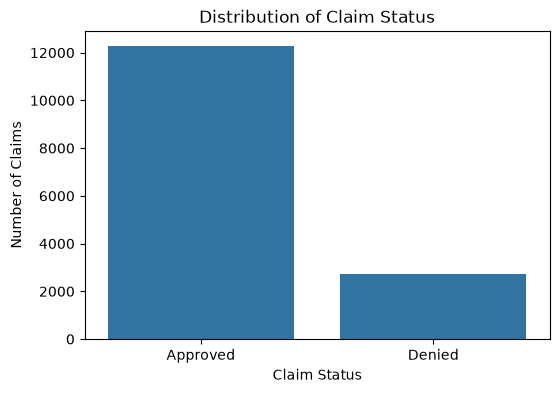

In [7]:

plt.figure(figsize=(6,4))
sns.countplot(data=eda, x="Claim_Status")
plt.title("Distribution of Claim Status")
plt.xlabel("Claim Status")
plt.ylabel("Number of Claims")
plt.show()

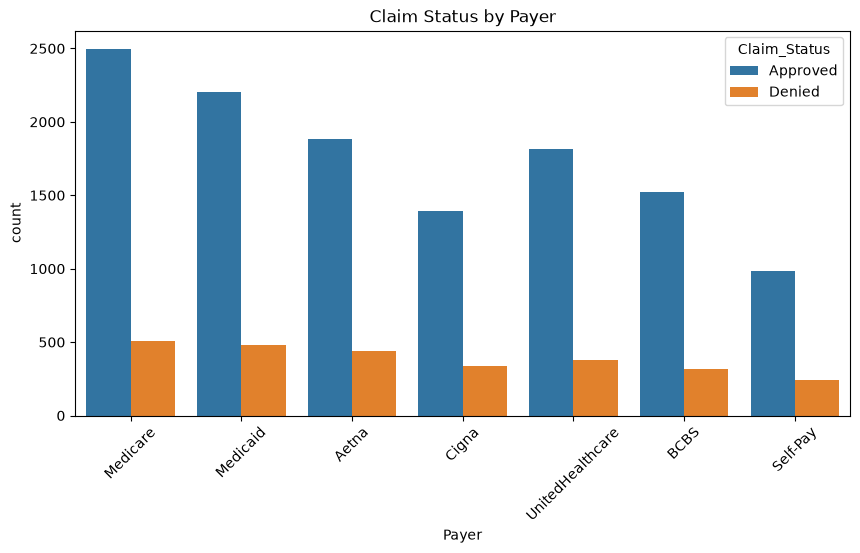

In [10]:
plt.figure(figsize=(10,5))
sns.countplot(data=eda, x="Payer", hue="Claim_Status")
plt.title("Claim Status by Payer")
plt.xticks(rotation=45)
plt.show()

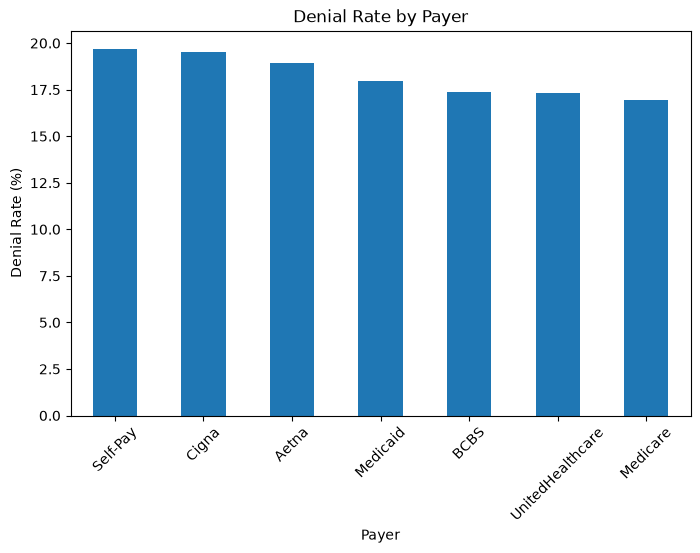

In [11]:
denial_rate = (
    eda.groupby("Payer")["Claim_Status"]
       .apply(lambda x: (x == "Denied").mean() * 100)
       .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
denial_rate.plot(kind="bar")
plt.title("Denial Rate by Payer")
plt.xlabel("Payer")
plt.ylabel("Denial Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [15]:
eda

,Claim_ID,Claim_Form_Type,Provider_NPI,Provider_Specialty,Payer,Place_of_Service_Code,Place_of_Service_Desc,Diagnosis_Code,Procedure_Code,Procedure_Desc,...,Eligibility_Verified,Duplicate_Claim_Flag,NCCI_Bundling_Flag,Clearinghouse_Validation_Passed,Provider_Monthly_Claim_Volume,Provider_Payer_Prior_Denial_Count,Chronic_Condition_Flag,Claim_Status,CARC_Code,Denial_Reason
0,CLM100000,837P,3579337979,Orthopedics,Medicare,23,Emergency Room,I10,29881,Knee arthroscopy/surgery,...,True,False,False,True,80,3,False,Approved,NaN,NaN
1,CLM100001,837I,9409175431,Internal Medicine,Medicaid,21,Inpatient Hospital,J18.9,36415,Blood draw,...,True,False,False,True,257,1,False,Approved,NaN,NaN
2,CLM100002,837P,1396263773,Radiology,Medicaid,11,Office,E78.5,99213,"Office visit, low complexity",...,True,False,False,True,135,2,True,Approved,NaN,NaN
3,CLM100003,837I,8670024292,Orthopedics,Aetna,22,Outpatient Hospital,M54.5,93000,EKG,...,True,False,False,True,290,2,True,Denied,CO-45,Charge exceeds fee schedule/contracted amount
4,CLM100004,837I,7425344331,Orthopedics,Medicare,21,Inpatient Hospital,K21.9,99213,"Office visit, low complexity",...,True,False,False,True,187,2,False,Approved,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,CLM114995,837I,4660502249,Neurology,Self-Pay,22,Outpatient Hospital,N39.0,72148,MRI lumbar spine,...,True,False,False,True,151,0,True,Approved,NaN,NaN
14996,CLM114996,837P,8894062374,Neurology,Self-Pay,23,Emergency Room,E78.5,71046,Chest X-ray,...,True,False,False,True,111,0,False,Approved,NaN,NaN
14997,CLM114997,837I,8013221213,Orthopedics,BCBS,21,Inpatient Hospital,I10,36415,Blood draw,...,False,False,True,True,46,1,False,Denied,CO-45,Charge exceeds fee schedule/contracted amount
14998,CLM114998,837P,9767528422,Dermatology,UnitedHealthcare,11,Office,I10,93000,EKG,...,True,False,False,True,143,2,False,Approved,NaN,NaN


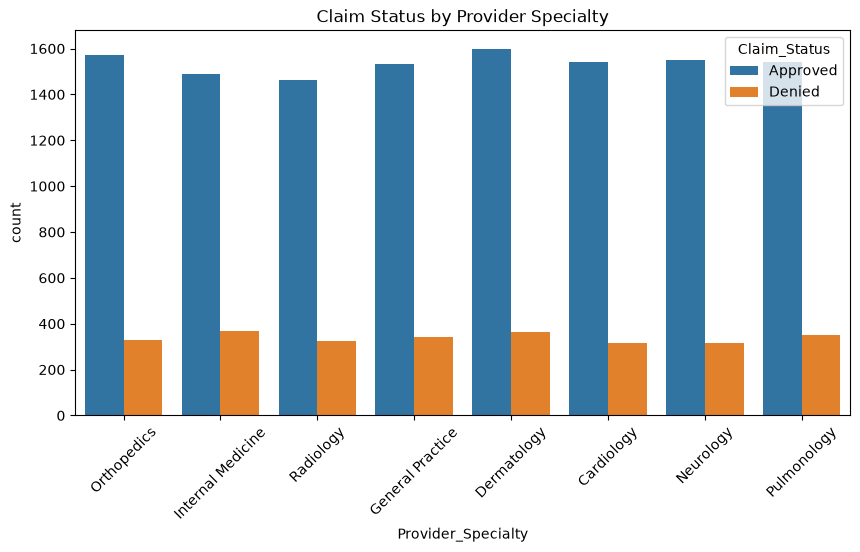

In [21]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=eda,
    x="Provider_Specialty",
    hue="Claim_Status"
)

plt.title("Claim Status by Provider Specialty")
plt.xticks(rotation=45)
plt.show()

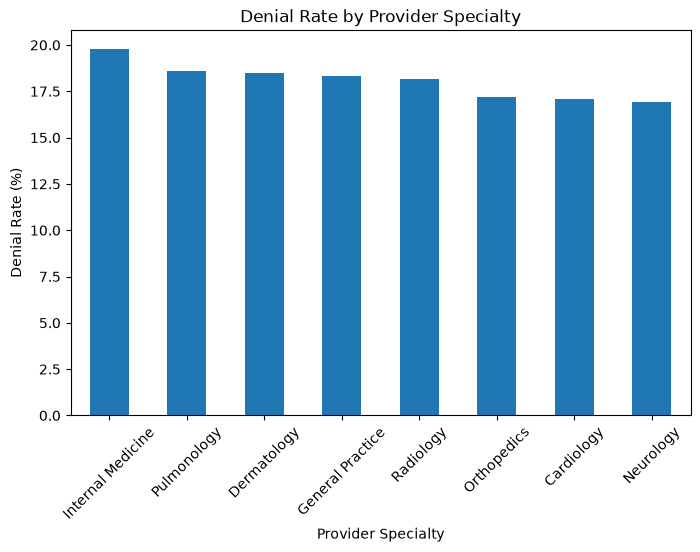

In [20]:
from re import M
from winsound import PlaySound


specialty_denial_rate = (
    eda.groupby("Provider_Specialty")["Claim_Status"]
       .apply(lambda x: (x == "Denied").mean() * 100)
         .sort_values(ascending=False))

plt.figure(figsize=(8,5))
specialty_denial_rate.plot(kind="bar")  

plt.title("Denial Rate by Provider Specialty")
plt.xlabel("Provider Specialty")
plt.ylabel("Denial Rate (%)")
plt.xticks(rotation=45)
plt.show()

Text(0.5, 1.0, 'Billed Amount by Claim Status')

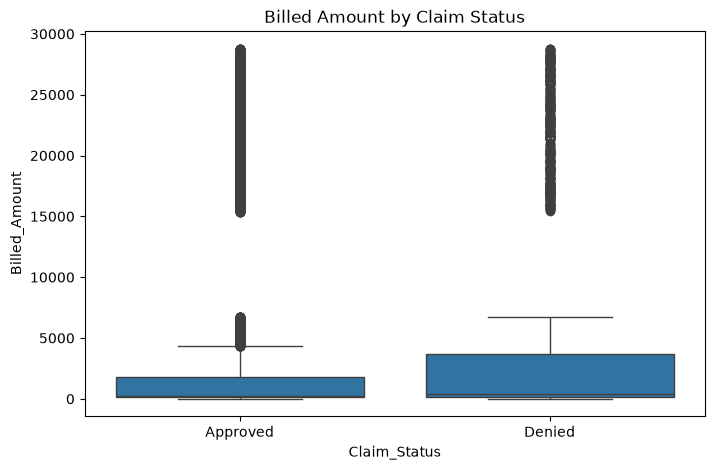

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda,
    x="Claim_Status",
    y="Billed_Amount"
)
plt.title("Billed Amount by Claim Status")


In [25]:
eda.to_csv("eda.csv", index=False)
